<a href="https://colab.research.google.com/github/NeelSampath/yolOnFb/blob/main/yoloOnFb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

verify the env

In [1]:
!nvidia-smi

Sat Feb 14 06:33:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

mount drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Image path

In [3]:
!ls /content/drive/MyDrive/AssOne/


 data  'Data set demo'	 data.zip   yoloOnFb.ipynb


UnZip the data .zip

In [5]:
!unzip /content/drive/MyDrive/AssOne/data.zip -d /content/drive/MyDrive/AssOne/data

Archive:  /content/drive/MyDrive/AssOne/data.zip
replace /content/drive/MyDrive/AssOne/data/classes.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/drive/MyDrive/AssOne/data/classes.txt  
replace /content/drive/MyDrive/AssOne/data/notes.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/drive/MyDrive/AssOne/data/notes.json  
replace /content/drive/MyDrive/AssOne/data/images/0246b085-frame_23.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/drive/MyDrive/AssOne/data/images/0246b085-frame_23.jpg  
replace /content/drive/MyDrive/AssOne/data/images/02f34865-frame_25.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/drive/MyDrive/AssOne/data/images/02f34865-frame_25.jpg  
replace /content/drive/MyDrive/AssOne/data/images/06b0d823-frame_7.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/drive/MyDrive/AssOne/data/images/06b0d823-frame_7.jpg  
  inflating: /content/drive/MyDrive/AssOne/data/images/089acace

Unziped folder

In [6]:
!ls /content/drive/MyDrive/AssOne/data/labels/

0246b085-frame_23.txt  639e48d1-frame_6.txt   c5af8c26-frame_44.txt
02f34865-frame_25.txt  6786213b-frame_47.txt  c5f93909-frame_33.txt
06b0d823-frame_7.txt   693ae953-frame_23.txt  c92848c2-frame_0.txt
089acace-frame_24.txt  69e8ae32-frame_10.txt  c9e0695f-frame_45.txt
0a5590a5-frame_27.txt  69e9f156-frame_20.txt  cb0fe6b9-frame_3.txt
0db2daef-frame_35.txt  69eb5e98-frame_9.txt   cb6decd9-frame_6.txt
0e2f0ccb-frame_1.txt   6a532292-frame_35.txt  cbc19c5c-frame_48.txt
0fbf80e8-frame_39.txt  6d0c4b8c-frame_19.txt  cdfeadf0-frame_18.txt
114e9ee7-frame_25.txt  7198622a-frame_16.txt  cf1f5f6e-frame_12.txt
11f4d776-frame_27.txt  74ea119c-frame_34.txt  d18e9471-frame_34.txt
1209143d-frame_19.txt  79013549-frame_22.txt  d2a8d274-frame_44.txt
12529977-frame_15.txt  7c4686e3-frame_7.txt   d75c0f0a-frame_26.txt
18693936-frame_23.txt  84a7648a-frame_4.txt   d7fcdf2f-frame_15.txt
1a522b3c-frame_4.txt   84aa0afa-frame_1.txt   d929f45c-frame_32.txt
1ba4e037-frame_15.txt  84f3976f-frame_31.txt  dd791

divide data set to trinning and validation for 10% and for trainning 90 %

In [7]:


import random
import shutil
from pathlib import Path


DATASET_ROOT = Path("/content/drive/MyDrive/AssOne/data")
TRAIN_RATIO = 0.9
IMAGE_EXTS = [".jpg", ".jpeg", ".png"]
random.seed(42)


images_src = DATASET_ROOT / "images"
labels_src = DATASET_ROOT / "labels"

images_train = images_src / "train"
images_val   = images_src / "val"
labels_train = labels_src / "train"
labels_val   = labels_src / "val"

for p in [images_train, images_val, labels_train, labels_val]:
    p.mkdir(parents=True, exist_ok=True)

images = [
    img for img in images_src.iterdir()
    if img.suffix.lower() in IMAGE_EXTS and img.is_file()
]

random.shuffle(images)
split = int(len(images) * TRAIN_RATIO)

train_imgs = images[:split]
val_imgs   = images[split:]

def move_pair(img_path, img_dst, lbl_dst):
    lbl_path = labels_src / f"{img_path.stem}.txt"
    shutil.move(str(img_path), img_dst / img_path.name)

    if lbl_path.exists():
        shutil.move(str(lbl_path), lbl_dst / lbl_path.name)
    else:
        print(f"Missing label: {img_path.name}")

for img in train_imgs:
    move_pair(img, images_train, labels_train)

for img in val_imgs:
    move_pair(img, images_val, labels_val)

print("Dataset split complete")
print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)}")



Dataset split complete
Train: 90 | Val: 10


Ultralytics

In [8]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.4 MB/s eta 0:00:00


In [9]:
!pip show ultralytics



Name: ultralytics
Version: 8.4.14
Summary: Ultralytics YOLO 🚀 for SOTA object detection, multi-object tracking, instance segmentation, pose estimation and image classification.
Home-page: https://ultralytics.com
Author: 
Author-email: Glenn Jocher <glenn.jocher@ultralytics.com>, Jing Qiu <jing.qiu@ultralytics.com>
License: AGPL-3.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: matplotlib, numpy, opencv-python, pillow, polars, psutil, pyyaml, requests, scipy, torch, torchvision, ultralytics-thop
Required-by: 


Folder Structure

In [10]:
!ls -R /content/drive/MyDrive/ravenOne/yoloLineDetec4/data


/content/drive/MyDrive/ravenOne/yoloLineDetec4/data:
classes.txt  data.yaml	images	labels	notes.json

/content/drive/MyDrive/ravenOne/yoloLineDetec4/data/images:
train  val

/content/drive/MyDrive/ravenOne/yoloLineDetec4/data/images/train:
00bc243e-1st_year_repeat_-_A4_page-0021.jpg
04907c03-1st_Year_-_Repeat_page-0019.jpg
053ae14f-1st_Year_All_Results_page-0004.jpg
128b5d2b-1st_year_repeat_-_A4_page-0019.jpg
15e7f3db-1st_year_repeat_-_A4_page-0006.jpg
193e073a-1st_Year_-_A4_page-0003.jpg
19faa898-1st_Year_All_Results_page-0007.jpg
1b5f43f5-1st_year_repeat_-_A4_page-0008.jpg
1eaf20fb-1st_year_repeat_-_A4_page-0017.jpg
1ee1ec03-1st_year_repeat_-_A4_page-0016.jpg
20849be9-1st_Year_page-0002.jpg
25fbc07c-1st_Year_-_Repeat_page-0012.jpg
2872a351-1st_year_repeat_page-0023.jpg
287405a4-1st_Year_All_Results_page-0021.jpg
3326f59c-1st_Year_-_A4_page-0002.jpg
335d311f-1st_Year_Repeat_page-0019.jpg
35c9d480-1st_Year_-_Repeat_page-0002.jpg
3c6fd5d4-1st_year_repeat_page-0020.jpg
3da1c190-1st_Year_

In [11]:

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml, dataset_root):
    """
    Creates YOLO data.yaml file from classes.txt
    """

    # Check classes.txt
    if not os.path.exists(path_to_classes_txt):
        raise FileNotFoundError(f"classes.txt not found: {path_to_classes_txt}")

    # Read class names
    with open(path_to_classes_txt, "r") as f:
        classes = [line.strip() for line in f if line.strip()]

    data = {
        "path": dataset_root,
        "train": "images/train",
        "val": "images/val",
        "nc": len(classes),
        "names": classes
    }

    # Write YAML
    with open(path_to_data_yaml, "w") as f:
        yaml.dump(data, f, sort_keys=False)

    print(f"data.yaml created at: {path_to_data_yaml}")
    print(f"Classes ({len(classes)}): {classes}")


#path
dataset_root = "/content/drive/MyDrive/AssOne/data"
path_to_classes_txt = f"{dataset_root}/classes.txt"
path_to_data_yaml = f"{dataset_root}/data.yaml"

# Run
create_data_yaml(path_to_classes_txt, path_to_data_yaml, dataset_root)

print("\n data.yaml contents:\n")
!cat /content/drive/MyDrive/AssOne/data/data.yaml



data.yaml created at: /content/drive/MyDrive/AssOne/data/data.yaml
Classes (5): ['Ball', 'Goalkeeper', 'Referees', 'Team A', 'Team B']

 data.yaml contents:

path: /content/drive/MyDrive/AssOne/data
train: images/train
val: images/val
nc: 5
names:
- Ball
- Goalkeeper
- Referees
- Team A
- Team B


## Run yolo 11 S

In [12]:
!yolo detect train data=/content/drive/MyDrive/AssOne/data/data.yaml model=yolo11s.pt epochs=100 imgsz=640




Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/AssOne/data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

In [13]:
!yolo detect predict model=runs/detect/train/weights/best.pt source=/content/drive/MyDrive/AssOne/data/images/val save=True



Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs

image 1/10 /content/drive/MyDrive/AssOne/data/images/val/089acace-frame_24.jpg: 384x640 2 Refereess, 6 Team As, 3 Team Bs, 55.5ms
image 2/10 /content/drive/MyDrive/AssOne/data/images/val/1a522b3c-frame_4.jpg: 384x640 1 Ball, 2 Refereess, 8 Team As, 6 Team Bs, 10.8ms
image 3/10 /content/drive/MyDrive/AssOne/data/images/val/1ba4e037-frame_15.jpg: 384x640 1 Goalkeeper, 11 Team As, 13 Team Bs, 10.8ms
image 4/10 /content/drive/MyDrive/AssOne/data/images/val/238ec686-frame_32.jpg: 384x640 1 Ball, 1 Referees, 7 Team As, 10 Team Bs, 15.7ms
image 5/10 /content/drive/MyDrive/AssOne/data/images/val/52abd1bc-frame_45.jpg: 384x640 1 Ball, 2 Goalkeepers, 11 Team As, 6 Team Bs, 10.8ms
image 6/10 /content/drive/MyDrive/AssOne/data/images/val/5d554f50-frame_43.jpg: 384x640 1 Referees, 10 Team As, 10 Team Bs, 10.8ms
image 7/10 /content/dri

predictions

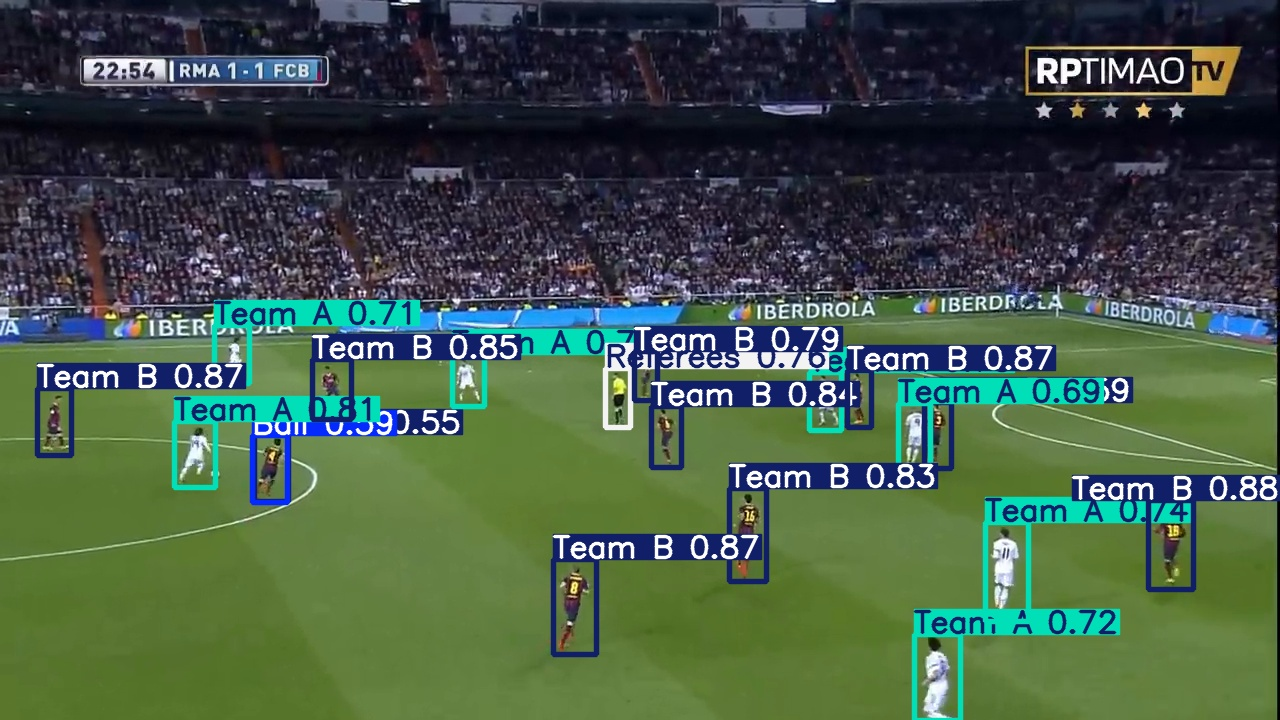

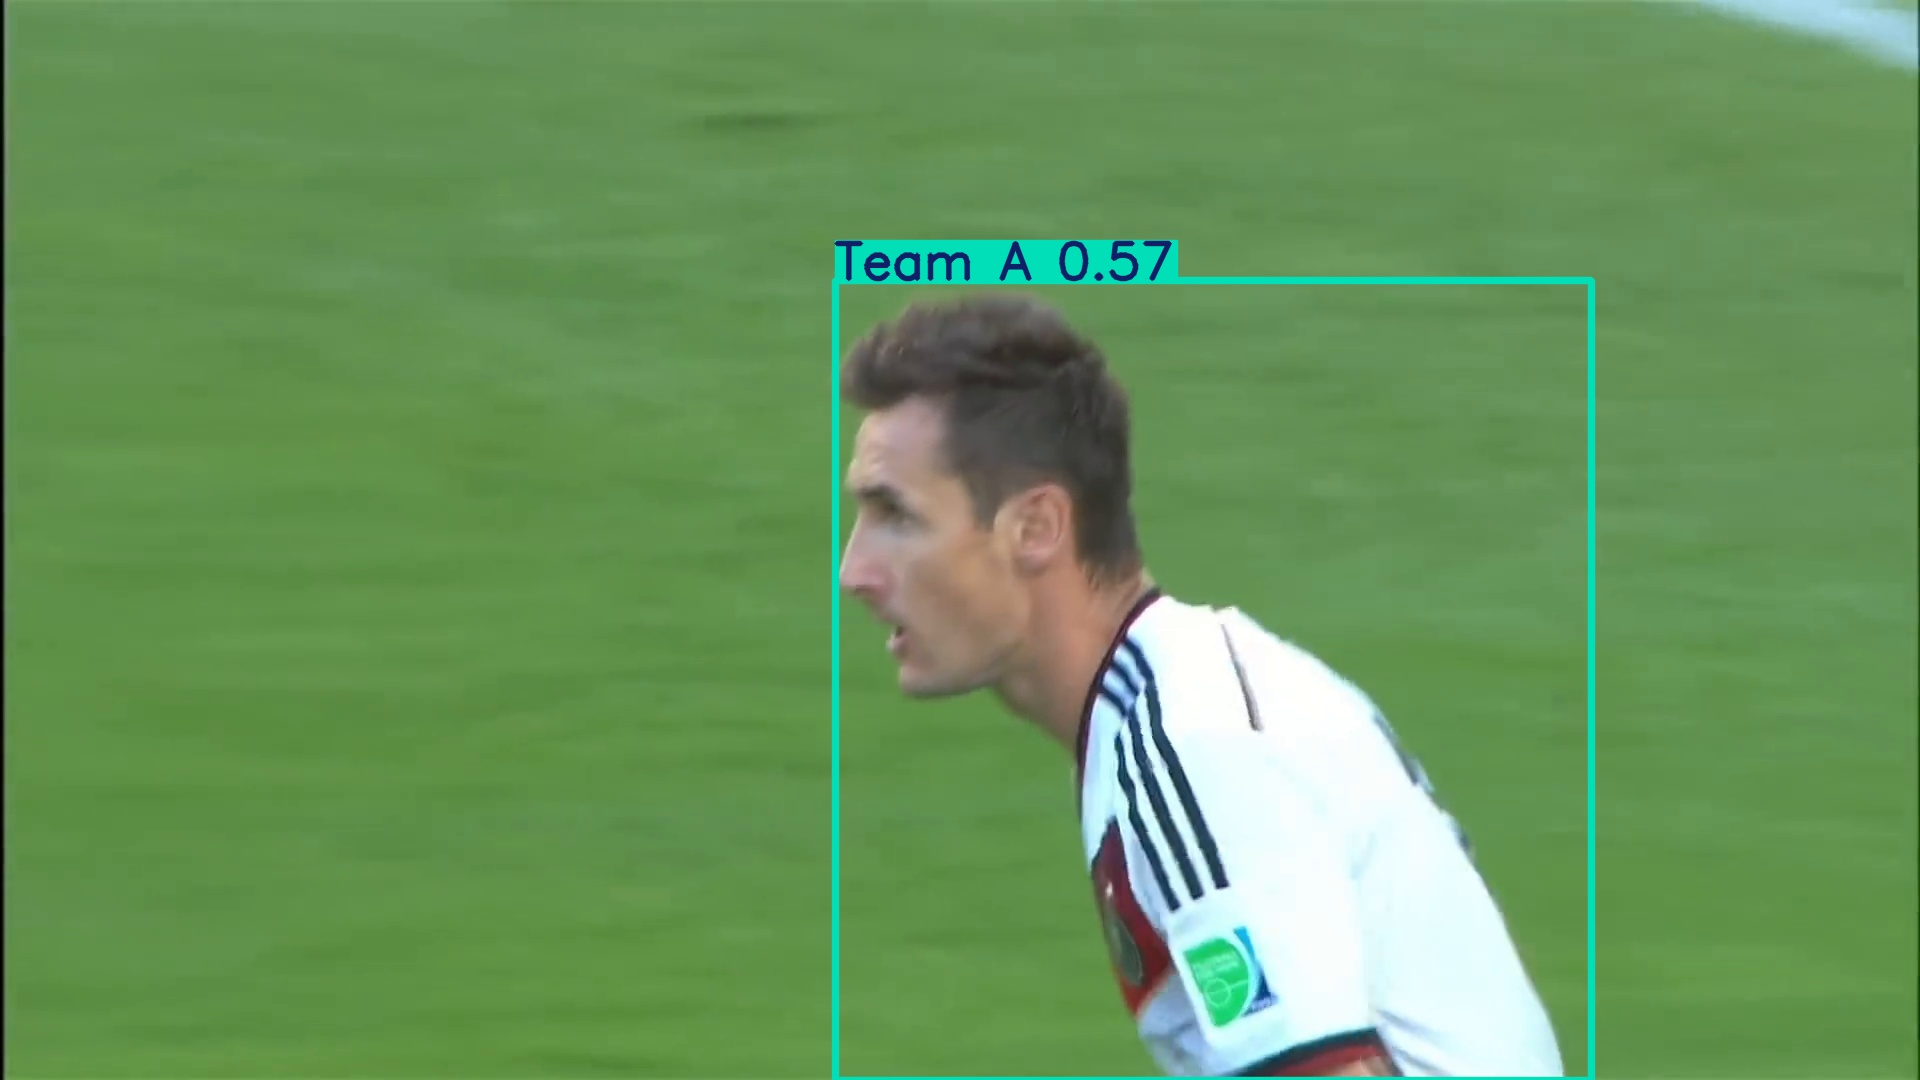

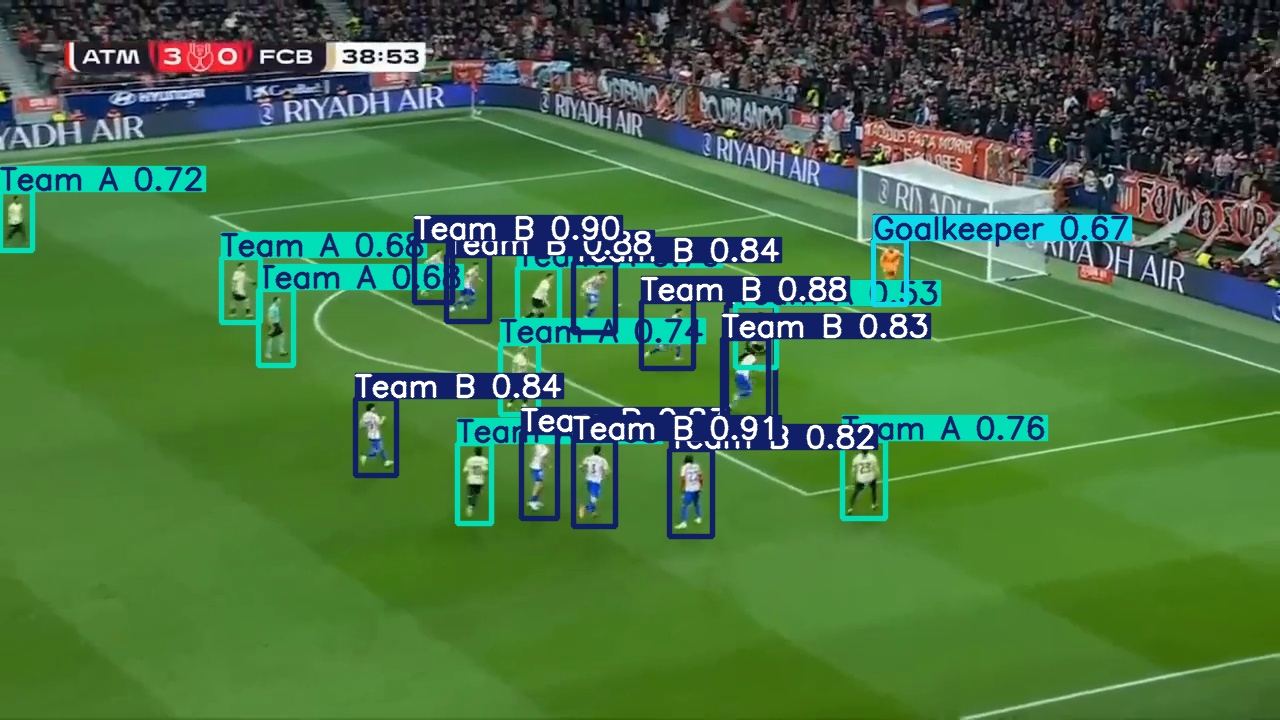

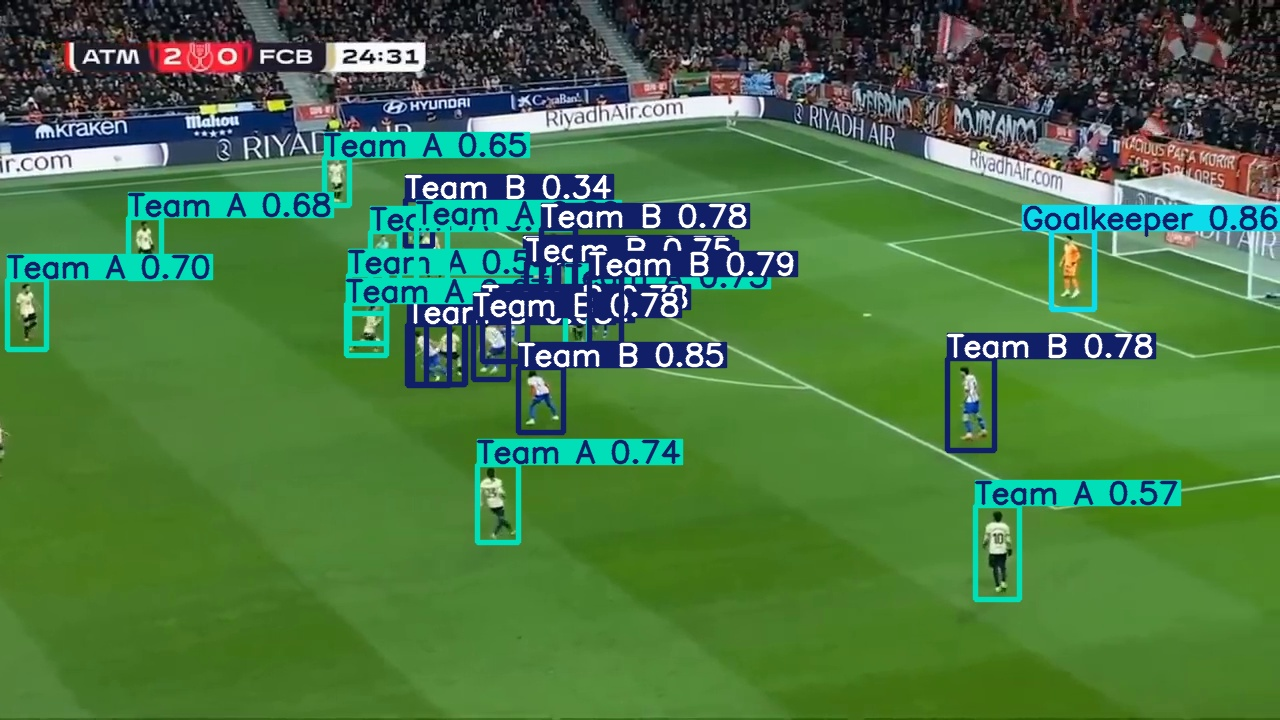

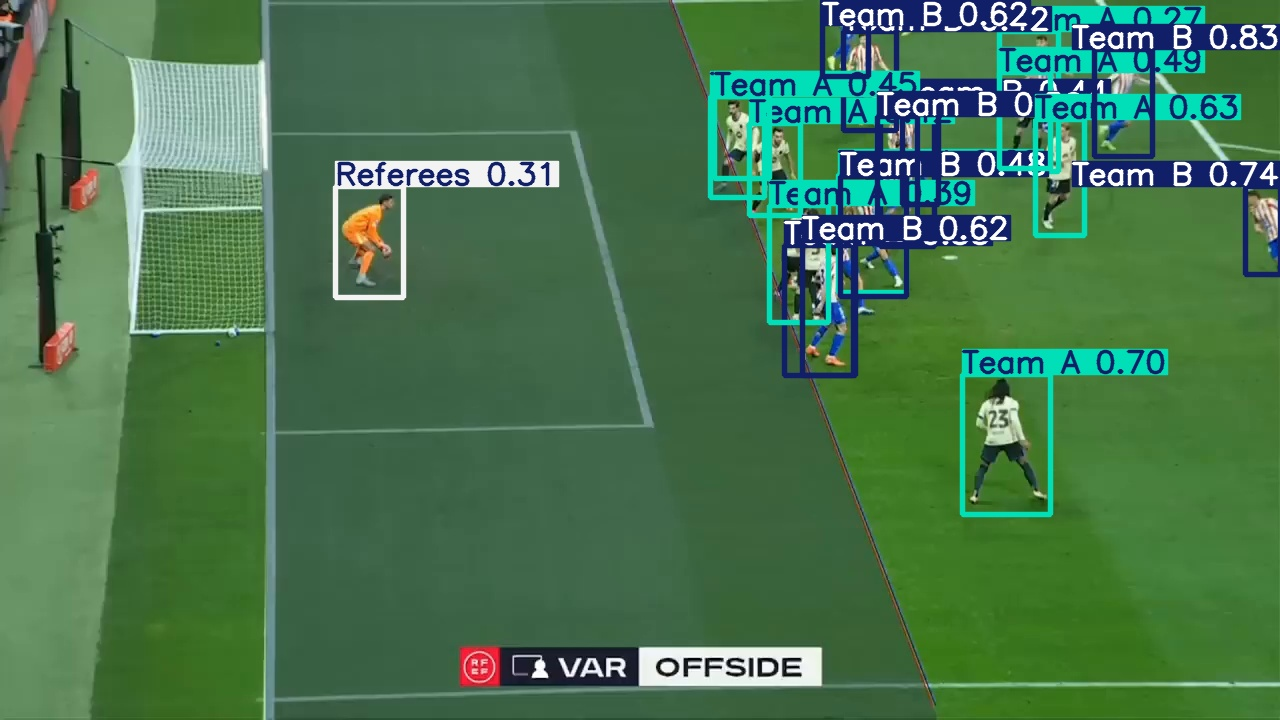

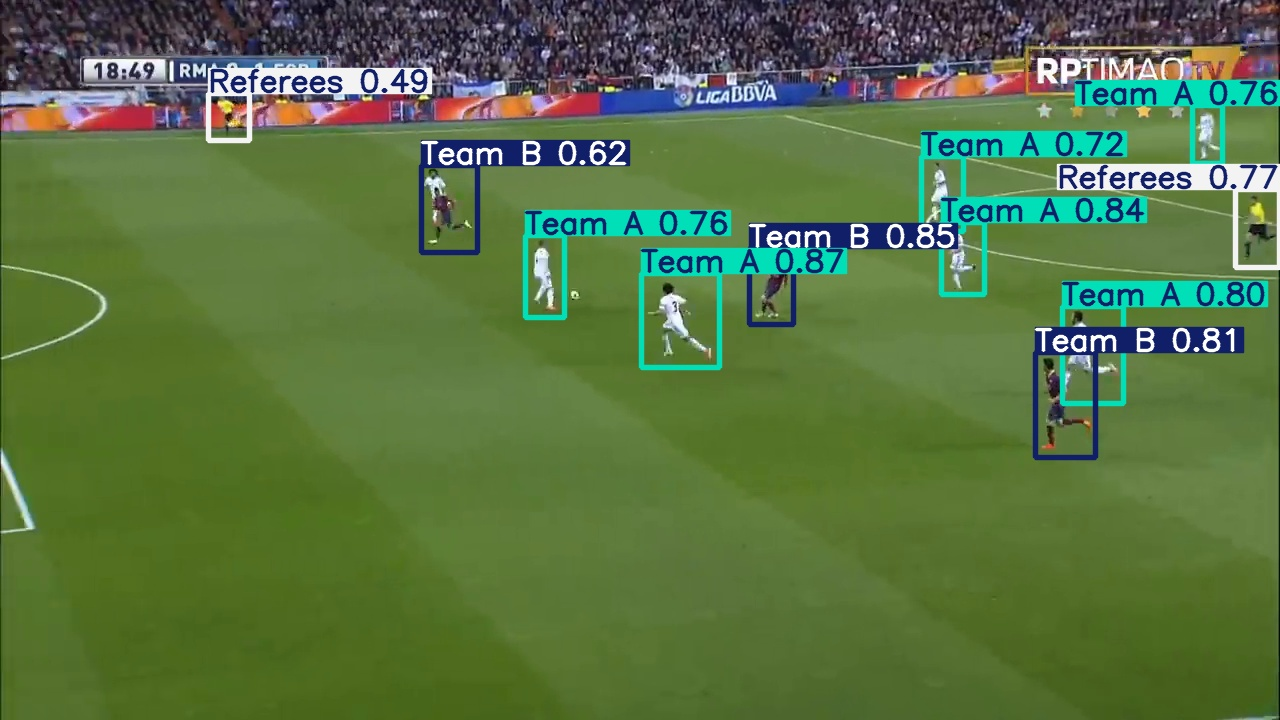

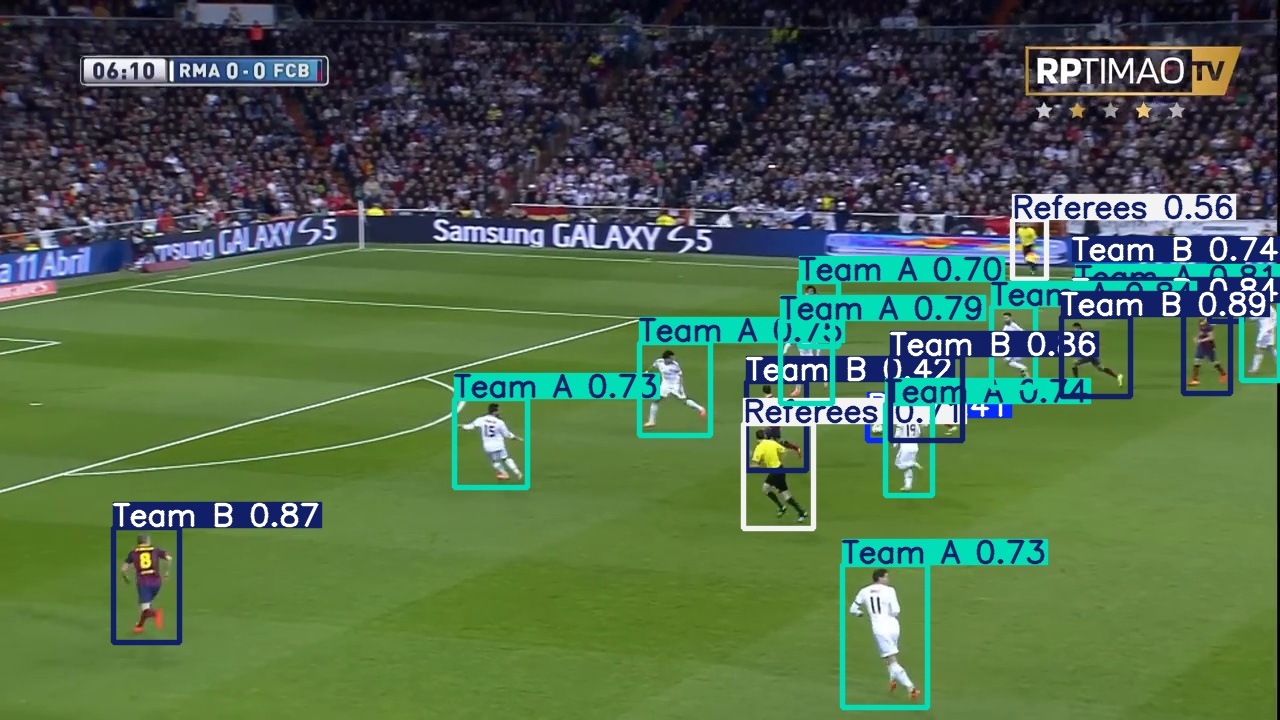

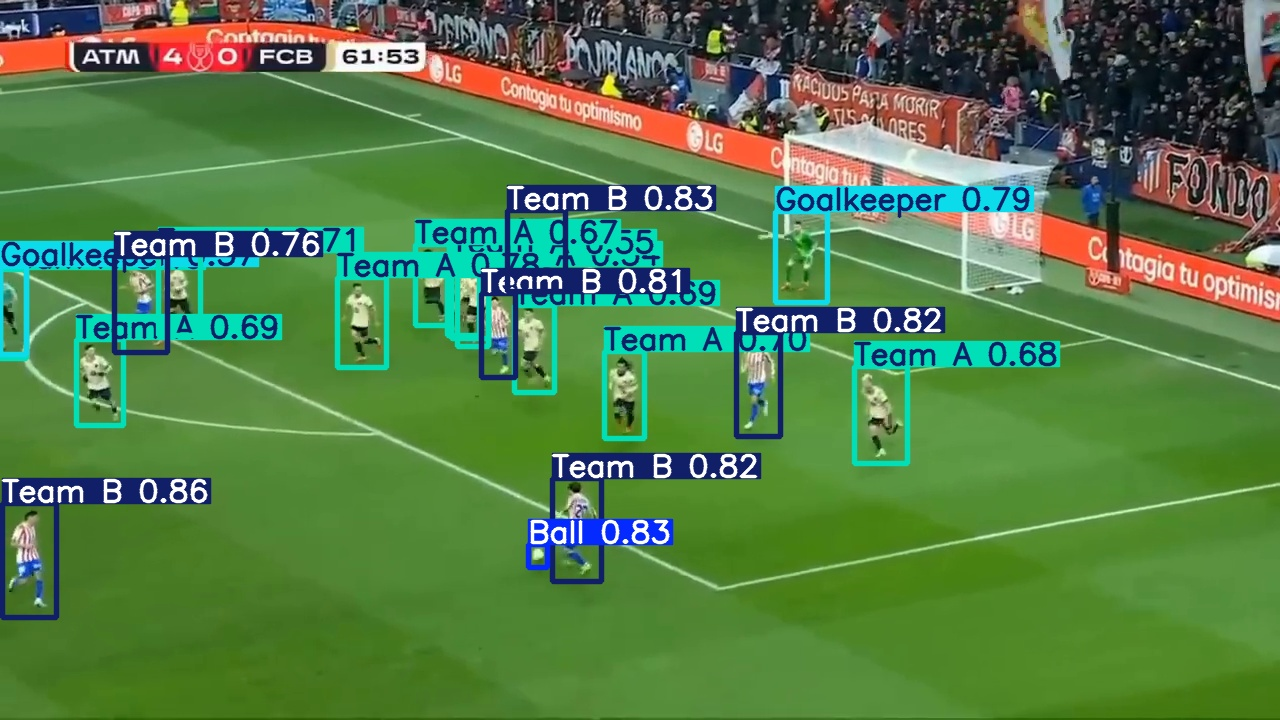

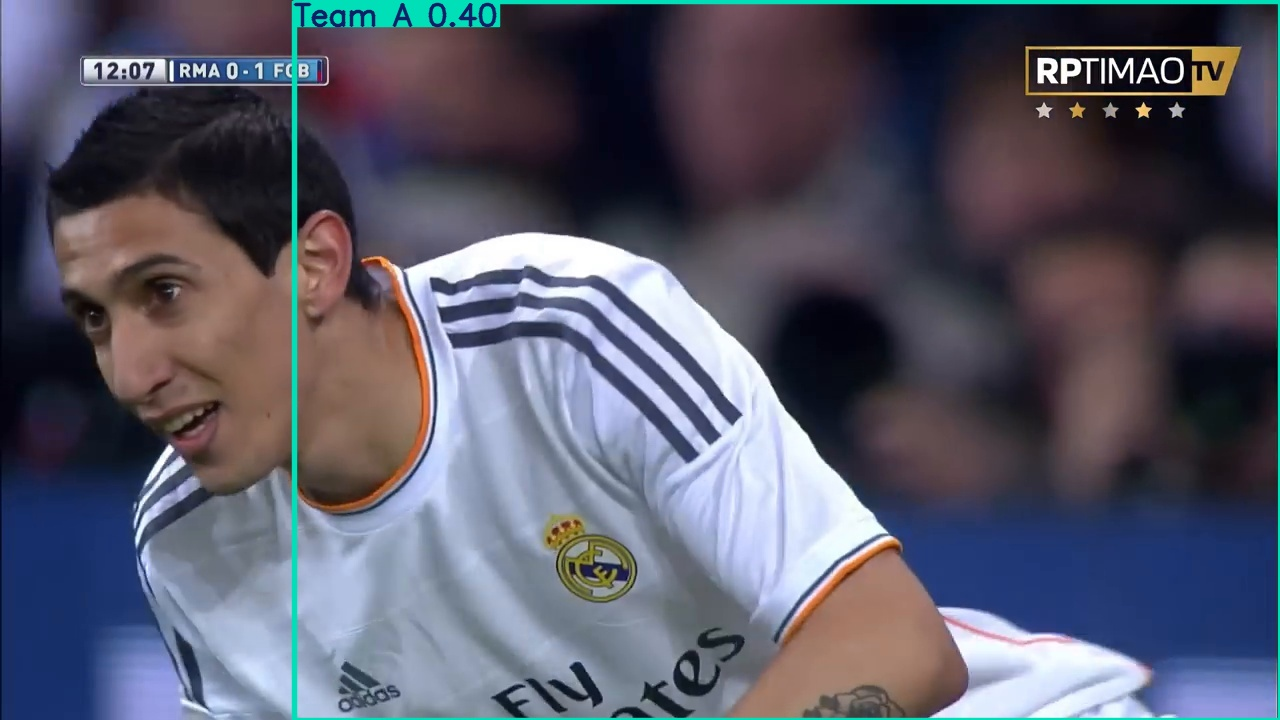

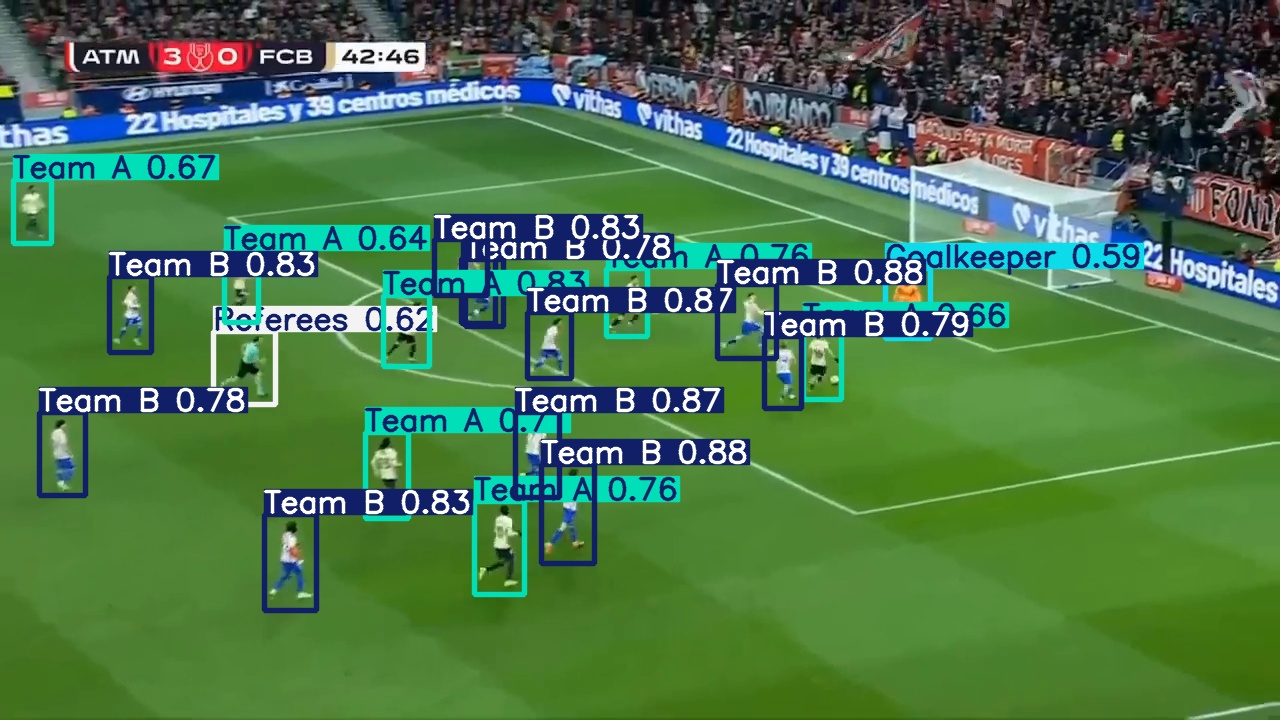

In [14]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')

In [26]:
!ls /content/drive/MyDrive/AssOne/

best.pt  data  DataSetDemo  data.zip  yoloOnFb.ipynb


In [24]:
!zip -r yolo_training_results.zip /content/runs/detect/train


  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/train_batch0.jpg (deflated 6%)
  adding: content/runs/detect/train/labels.jpg (deflated 38%)
  adding: content/runs/detect/train/BoxR_curve.png (deflated 9%)
  adding: content/runs/detect/train/args.yaml (deflated 52%)
  adding: content/runs/detect/train/BoxP_curve.png (deflated 9%)
  adding: content/runs/detect/train/confusion_matrix.png (deflated 27%)
  adding: content/runs/detect/train/BoxPR_curve.png (deflated 13%)
  adding: content/runs/detect/train/weights/ (stored 0%)
  adding: content/runs/detect/train/weights/best.pt (deflated 8%)
  adding: content/runs/detect/train/weights/last.pt (deflated 8%)
  adding: content/runs/detect/train/train_batch1.jpg (deflated 5%)
  adding: content/runs/detect/train/train_batch540.jpg (deflated 13%)
  adding: content/runs/detect/train/val_batch0_pred.jpg (deflated 9%)
  adding: content/runs/detect/train/BoxF1_curve.png (deflated 8%)
  adding: content/runs/detect/

In [25]:
from google.colab import files
files.download("yolo_training_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

load my model

In [28]:
from ultralytics import YOLO

# Load your trained model
model = YOLO("/content/drive/MyDrive/AssOne/best.pt")

# Run prediction on video
results = model.predict(
    source="/content/drive/MyDrive/AssOne/testFb.mp4",
    conf=0.25,
    save=True
)



WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1236) /content/drive/MyDrive/AssOne/testFb.mp4: 352x640 1 Ball, 1 Goalkeeper, 4 Team As, 7 Team Bs, 53.8ms
video 1/1 (frame 2/1236) /content/drive/MyDrive/AssOne/testFb.mp4: 352x640 1 Ball, 1 Goalkeeper, 4 Team As, 7 Team Bs, 11.1ms
video 1/1 (frame 3/1236) /content/drive/MyDrive/AssOne/testFb.mp4: 352x640 1 Ball, 1 Goalkeeper, 4 Team As, 7 Team Bs, 10.8ms
video 1/1 (frame 4/1236) /content/drive/MyDrive/AssOne/testFb.mp4: 352x640 1 Bal

In [27]:
!ls /content/drive/MyDrive/AssOne/

best.pt  data  DataSetDemo  data.zip  testFb.mp4  yoloOnFb.ipynb


to download local pc

In [29]:
from google.colab import files
files.download("/content/runs/detect/predict2/testFb.avi")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>